In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from collections import Counter
import re
from wordcloud import WordCloud, STOPWORDS
from geopy.geocoders import Nominatim
import folium
import time
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [131]:
df = pd.read_csv('fatalities_isr_pse_conflict_2000_to_2023.csv')
df.head()

,name,date_of_event,age,citizenship,event_location,event_location_district,event_location_region,date_of_death,gender,took_part_in_the_hostilities,place_of_residence,place_of_residence_district,type_of_injury,ammunition,killed_by,notes
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,"Fatally shot by Israeli forces while standing on the roof of his home, watching clashes that erupted between them and young men after the forces entered the camp. During the forces’ incursion into the camp, another Palestinian was killed while fleeing the forces. According to the IDF Spokesperson, a soldier was moderately injured by shrapnel."
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,"Fatally shot by Israeli forces while trying to flee them after watching clashes that erupted after they entered the camp and included a fire exchange. Abu ‘Ali was a Hamas military wing operative. During the forces’ incursion into the camp, another Palestinian was killed while standing on the roof of his house. According to the IDF Spokesperson, a soldier was moderately injured by shrapnel."
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16.0,Palestinian,Kfar Dan,Jenin,West Bank,2023-09-22,M,NaN,al-Yamun,Jenin,gunfire,live ammunition,Israeli security forces,Fatally shot by soldiers while firing at them with an improvised gun during a fire exchange that erupted after they entered the village. Abu Hassan was an Islamic Jihad military wing operative.
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19.0,Palestinian,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,NaN,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Israeli security forces,Shot in the head by Israeli forces while throwing stones at them in clashes that erupted after they entered the camp and during which explosive devices were thrown at the forces.
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15.0,Palestinian,Jenin R.C.,Jenin,West Bank,2023-09-19,M,NaN,Jenin,Jenin,gunfire,live ammunition,Israeli security forces,Wounded by soldiers’ gunfire after running away from them as they entered the camp. Soldiers also fired at a man who tried to evacuate him but did not hit him. Khamaiseh subsequently died of his wounds. Two Islamic Jihad military wing operatives were also killed in the incident. Another operative was wounded by the shrapnel and died of his wounds on 20 September 2023.


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11124 entries, 0 to 11123
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          11124 non-null  object 
 1   date_of_event                 11124 non-null  object 
 2   age                           10995 non-null  float64
 3   citizenship                   11124 non-null  object 
 4   event_location                11124 non-null  object 
 5   event_location_district       11124 non-null  object 
 6   event_location_region         11124 non-null  object 
 7   date_of_death                 11124 non-null  object 
 8   gender                        11104 non-null  object 
 9   took_part_in_the_hostilities  9694 non-null   object 
 10  place_of_residence            11056 non-null  object 
 11  place_of_residence_district   11056 non-null  object 
 12  type_of_injury                10833 non-null  object 
 13  a

In [133]:
df.isnull().sum()

name                               0
date_of_event                      0
age                              129
citizenship                        0
event_location                     0
event_location_district            0
event_location_region              0
date_of_death                      0
gender                            20
took_part_in_the_hostilities    1430
place_of_residence                68
place_of_residence_district       68
type_of_injury                   291
ammunition                      5253
killed_by                          0
notes                            280
dtype: int64

In [134]:
df.describe().round(0).T

,count,mean,std,min,25%,50%,75%,max
age,10995.0,27.0,14.0,1.0,19.0,23.0,31.0,112.0


In [135]:
df['age'].fillna(df['age'].mean().round(0), inplace=True)

In [136]:
df['age'] = df['age'].astype(int)

In [137]:
df['date_of_event'] = pd.to_datetime(df['date_of_event'])
df['date_of_death'] = pd.to_datetime(df['date_of_death'])

In [138]:
df['gender'].value_counts(dropna=False)

gender
M      9681
F      1423
NaN      20
Name: count, dtype: int64

In [139]:
df['gender'] = df['gender'].fillna('Unknown')
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female'})

In [140]:
df['gender'].value_counts(dropna=False)

gender
Male       9681
Female     1423
Unknown      20
Name: count, dtype: int64

In [141]:
df['took_part_in_the_hostilities'].value_counts()

took_part_in_the_hostilities
No                            4653
Yes                           3467
Israelis                       771
Unknown                        603
Object of targeted killing     200
Name: count, dtype: int64

In [142]:
df['took_part_in_the_hostilities'].fillna('Unknown', inplace=True)
df['place_of_residence'].fillna('Unknown', inplace=True)
df['place_of_residence_district'].fillna('Unknown', inplace=True)
df['type_of_injury'].fillna('Unknown', inplace=True)
df['ammunition'].fillna('Unknown', inplace=True)
df['notes'].fillna('Unknown', inplace=True)

In [143]:
text = ' '.join(df['notes'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

In [181]:
Counter(text.split()).most_common(10)

[('killed', 10656),
 ('home', 1981),
 ('family', 1696),
 ('soldiers', 1625),
 ('military', 1588),
 ('two', 1545),
 ('shot', 1426),
 ('idf', 1302),
 ('near', 1296),
 ('house', 1270)]

In [145]:
words = [word for word in text.split() if word not in stopwords and len(word) > 1]

word_freq = Counter(words)

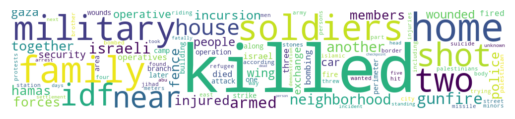

In [245]:
wordcloud = WordCloud(width=1000, height=200, background_color='white', max_words=100).generate_from_frequencies(word_freq)

# plt.figure(figsize=(5, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
# plt.title("Israeli-Palestinian Conflict Word Cloud")
plt.show()

In [147]:
df['date_difference'] = df['date_of_death'] - df['date_of_event']
df['date_difference'] = df['date_difference'].dt.days
df = df[df['date_difference'] >= 0]

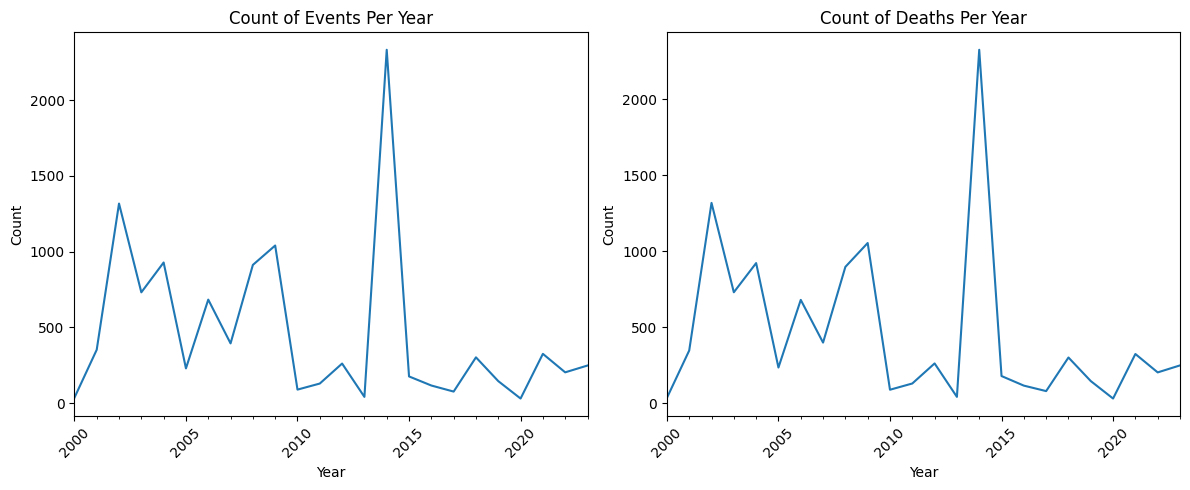

In [189]:
event_count = df['date_of_event'].dt.to_period('Y').value_counts().sort_index()
death_count = df['date_of_death'].dt.to_period('Y').value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
event_count.plot(kind='line')
plt.title("Count of Events Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1,2,2)
death_count.plot(kind='line')
plt.title("Count of Deaths Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [239]:
df['date_of_death'].dt.to_period('Y').value_counts().sort_index()

date_of_death
2000      35
2001     347
2002    1318
2003     730
2004     922
2005     235
2006     680
2007     399
2008     897
2009    1054
2010      89
2011     130
2012     262
2013      42
2014    2325
2015     179
2016     116
2017      80
2018     301
2019     146
2020      31
2021     324
2022     203
2023     249
Freq: Y-DEC, Name: count, dtype: int64

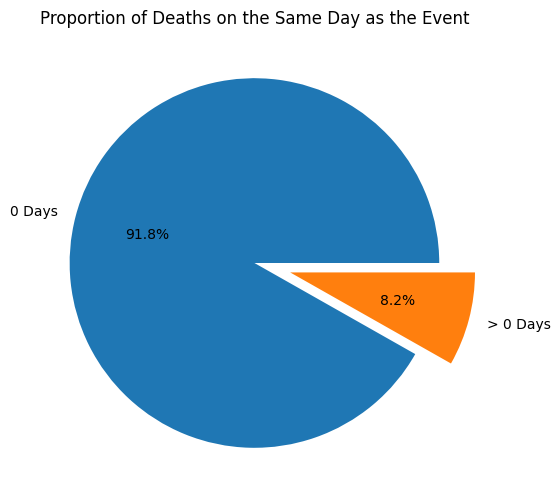

In [190]:
labels = ['0 Days', '> 0 Days']
sizes = [
    (df['date_difference'] == 0).sum(),
    (df['date_difference'] > 0).sum()
]
explode = [0, 0.2]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, explode=explode, autopct='%.1f%%', startangle=0)
plt.title("Proportion of Deaths on the Same Day as the Event")
plt.show()

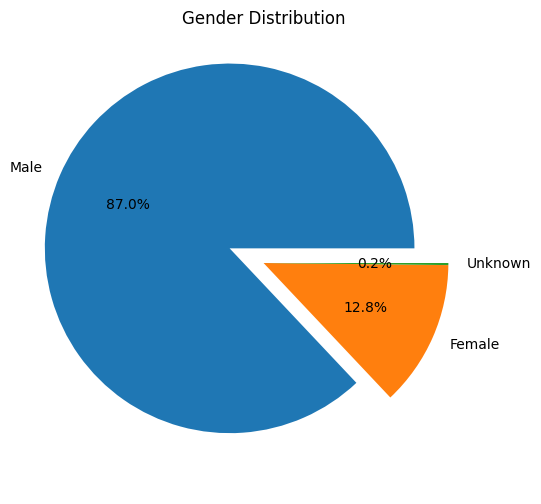

In [231]:
gender = df['gender'].value_counts()
labels = ['Male', 'Female', 'Unknown']
explode = [0.2, 0, 0]

plt.figure(figsize=(6,6))
plt.pie(gender, labels=labels, explode=explode, autopct='%.1f%%', startangle=0)
plt.title('Gender Distribution')
plt.show()

In [154]:
df['age'].value_counts().sort_index()

age
1       59
2       70
3       62
4       64
5       55
6       48
7       66
8       47
9       80
10      81
11      87
12      91
13     153
14     196
15     275
16     388
17     408
18     387
19     534
20     587
21     609
22     629
23     578
24     483
25     490
26     382
27     481
28     315
29     229
30     260
31     171
32     206
33     169
34     145
35     159
36     133
37      96
38     104
39      96
40     115
41      77
42      80
43      76
44      63
45      91
46      57
47      53
48      73
49      54
50      78
51      54
52      54
53      51
54      50
55      49
56      39
57      27
58      41
59      26
60      32
61      19
62      31
63      30
64      29
65      29
66      22
67      23
68      15
69      12
70      22
71      14
72      13
73      12
74       8
75      16
76       6
77      12
78      10
79      14
80       4
81       6
82       8
83       1
84       4
85       6
86       3
87       3
88       1
89       1
90       1
91    

In [ ]:
import matplotlib.pyplot as plt

age_counts = df['age'].value_counts().sort_index()

plt.figure(figsize=(12, 8))

# Bar plot
plt.bar(age_counts.index, age_counts.values, color='lightblue', label='Bar')

# Garis + marker bulat
plt.plot(age_counts.index, age_counts.values, color='red', marker='o', linewidth=2, label='Line with markers')

# Label dan judul
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


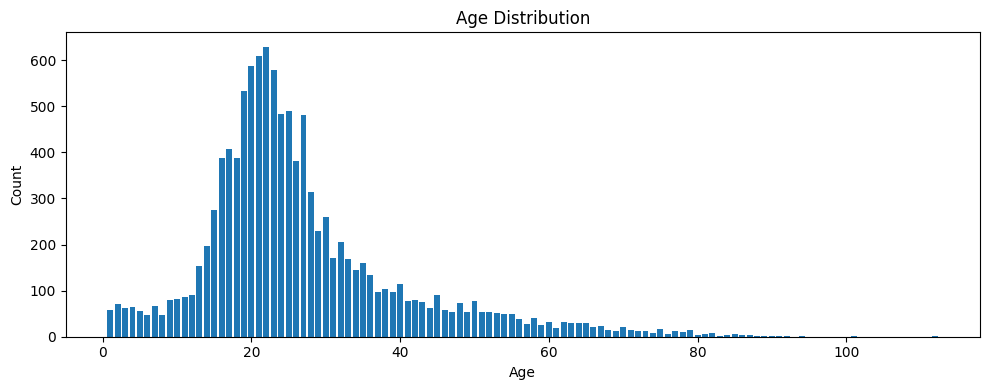

In [241]:
age_counts = df['age'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(age_counts.index, age_counts.values)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [242]:
df['age'].describe()

count    11094.000000
mean        26.750225
std         13.694122
min          1.000000
25%         19.000000
50%         23.000000
75%         31.000000
max        112.000000
Name: age, dtype: float64

In [229]:
df['citizenship'].value_counts().sort_index()

citizenship
American           1
Israeli         1028
Jordanian          1
Palestinian    10064
Name: count, dtype: int64

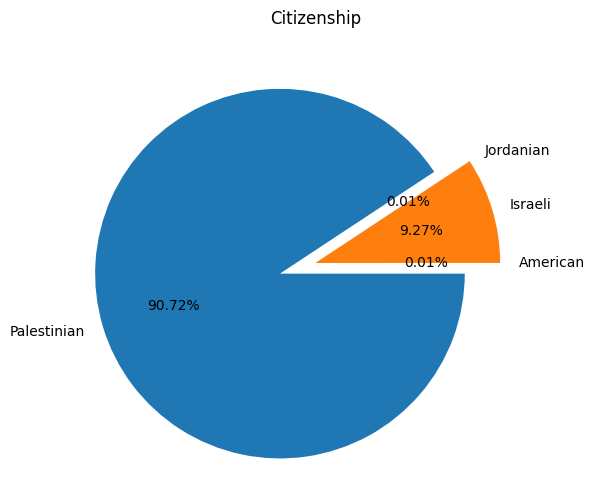

In [230]:
citizenship = df['citizenship'].value_counts().sort_index()
labels = ['American', 'Israeli', 'Jordanian', 'Palestinian']
explode = [0, 0, 0, 0.2]

plt.figure(figsize=(6,6))
plt.pie(citizenship, labels=citizenship.index, explode=explode, autopct='%.2f%%', startangle=0, colors=['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4'])
plt.title('Citizenship')
plt.show()

In [158]:
df['took_part_in_the_hostilities'].value_counts()

took_part_in_the_hostilities
No                            4635
Yes                           3465
Unknown                       2024
Israelis                       770
Object of targeted killing     200
Name: count, dtype: int64

In [159]:
df['type_of_injury'].value_counts()

type_of_injury
gunfire                         9824
explosion                        555
shelling                         309
Unknown                          289
stabbing                          48
house demolition                  25
hit by a vehicle                  18
beating                            8
stones throwing                    6
being bludgeoned with an axe       4
fire                               4
physically assaulted               2
physical assault                   1
Strangulation                      1
Name: count, dtype: int64

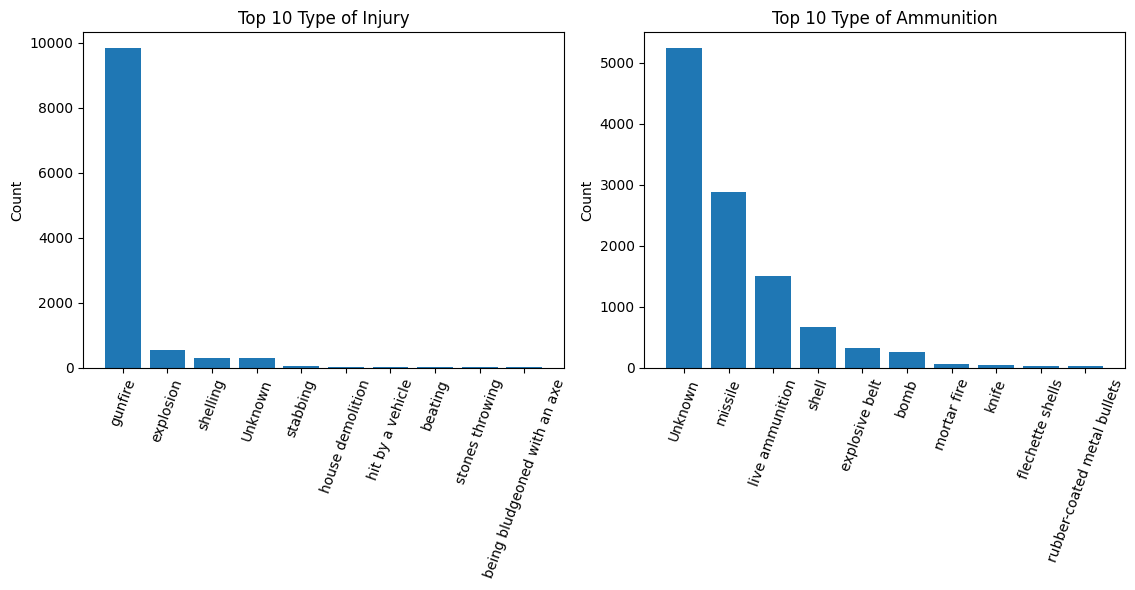

In [236]:
injury_counts = df['type_of_injury'].value_counts().sort_values(ascending=False).head(10)
ammunition_counts = df['ammunition'].value_counts().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Top 10 Type of Injury")
plt.ylabel("Count")
plt.bar(injury_counts.index, injury_counts.values)
plt.tight_layout()
plt.xticks(rotation=70)

plt.subplot(1, 2, 2)
plt.title("Top 10 Type of Ammunition")
plt.ylabel("Count")
plt.bar(ammunition_counts.index, ammunition_counts.values)
plt.tight_layout()
plt.xticks(rotation=70)
plt.show()

In [160]:
df['ammunition'].value_counts()

ammunition
Unknown                        5233
missile                        2874
live ammunition                1509
shell                           673
explosive belt                  326
bomb                            249
mortar fire                      51
knife                            37
flechette shells                 22
rubber-coated metal bullets      19
0.22-caliber bullets             16
phosphorus shell                 16
Qassam rocket                    15
car bomb                         15
teargas canister                 13
rocket                           12
grad rocket                       7
sponge rounds                     2
grenade                           2
flare bomb                        1
stun grenade                      1
rock                              1
Name: count, dtype: int64

In [165]:
df['killed_by'].value_counts()

killed_by
Israeli security forces    9971
Palestinian civilians      1027
Israeli civilians            96
Name: count, dtype: int64

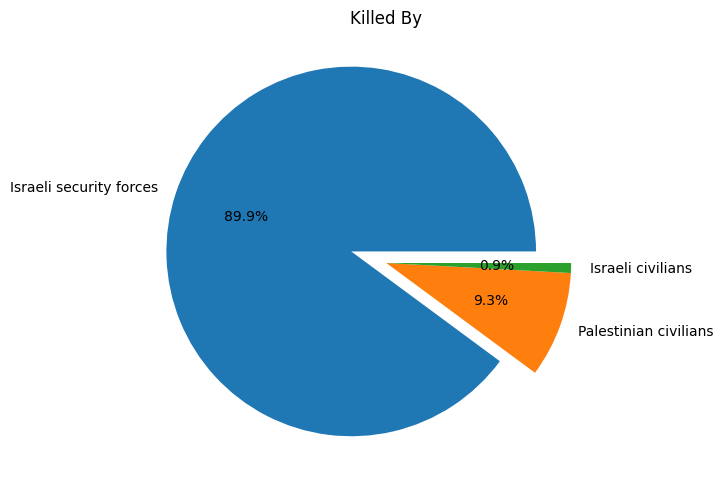

In [219]:
labels = ['Israeli security forces', 'Palestinian civilians', 'Israeli civilians']
killed_by = df['killed_by'].value_counts()
explode = [0.2, 0, 0]

plt.figure(figsize=(6, 6))
plt.pie(killed_by, labels=labels, explode=explode, autopct='%.1f%%', startangle=0)
plt.title("Killed By")
plt.show()

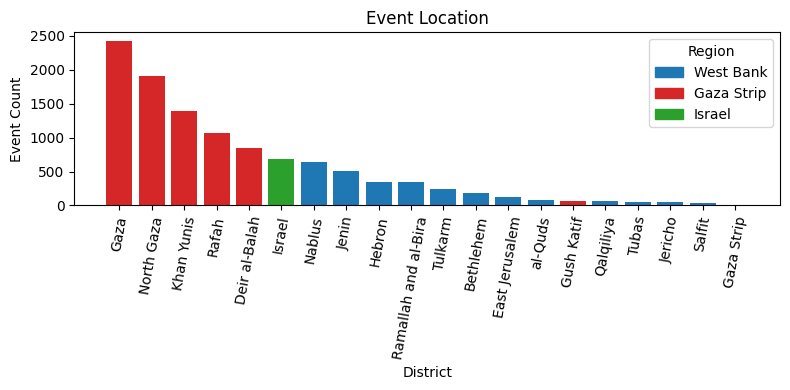

In [243]:
import matplotlib.pyplot as plt

# Hitung jumlah per distrik
location = df['event_location_district'].value_counts().sort_values(ascending=False)

# Mapping distrik ke region
district_region_map = df[['event_location_district', 'event_location_region']].drop_duplicates().set_index('event_location_district')['event_location_region'].to_dict()

# Siapkan label dan warna berdasarkan region
bar_labels = [district_region_map[d] for d in location.index]
region_colors = {
    'West Bank': 'tab:blue',
    'Gaza Strip': 'tab:red',
    'Israel': 'tab:green'
}
bar_colors = [region_colors.get(district_region_map[d], 'tab:gray') for d in location.index]

# Buat plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(location.index, location.values, label=bar_labels, color=bar_colors)

ax.set_ylabel('Event Count')
ax.set_xlabel('District')
ax.set_title('Event Location')
ax.set_xticklabels(location.index, rotation=80)

# Tambahkan legend manual (karena label di .bar tidak otomatis jadi legend)
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_handles, title='Region')

plt.tight_layout()
plt.show()
